# SALARY PREDICTOR MODEL AI AND DATASET

# Prefaces

## Player Rating Data:
### 20 GP min, EV Only 2024 Data, Goalies Not included

### Cap Data pulled from (https://capwages.com/)

### Features to add: Term, and age of player



--- Model Performance Summary (Linear Regression with Multiple Features)

--- Mean Absolute Error (MAE): $1,460,923

--- R-squared (R2): 0.5756

### FOLLOW INSTRUCTIONS AND RUN THE CELLS

In [40]:
import re, json, requests, pandas as pd
from pathlib import Path

TEAM_SLUGS = [
    # Atlantic
    "boston_bruins","buffalo_sabres","detroit_red_wings","florida_panthers",
    "montreal_canadiens","ottawa_senators","tampa_bay_lightning","toronto_maple_leafs",
    # Metropolitan
    "carolina_hurricanes","columbus_blue_jackets","new_jersey_devils",
    "new_york_islanders","new_york_rangers","philadelphia_flyers",
    "pittsburgh_penguins","washington_capitals",
    # Central
    "chicago_blackhawks","colorado_avalanche","dallas_stars","minnesota_wild",
    "nashville_predators","st_louis_blues","utah_mammoth","winnipeg_jets",
    # Pacific
    "anaheim_ducks","calgary_flames","edmonton_oilers","los_angeles_kings",
    "san_jose_sharks","seattle_kraken","vancouver_canucks","vegas_golden_knights",
]

# 1️⃣  Grab build-id dynamically from the depth charts page
html = requests.get("https://capwages.com/teams/montreal_canadiens/depth-charts").text
build_id = re.search(r'"buildId":"([^"]+)"', html).group(1)
print(f"Dynamically extracted buildId: {build_id}")


rows = []
for slug in TEAM_SLUGS:
    url = f"https://capwages.com/_next/data/{build_id}/teams/{slug}/depth-charts.json?team={slug}"
    response = requests.get(url)

    if response.status_code != 200:
        print(f"Warning: Received status code {response.status_code} for team: {slug}. Skipping.")
        continue

    try:
        data = response.json()
        # Check if 'gameDay' key exists before accessing it
        if "gameDay" in data.get("pageProps", {}):
            game_day_data = data["pageProps"]["gameDay"]
            # Check if 'lineup' key exists within gameDay data and it's a list
            if "lineup" in game_day_data and isinstance(game_day_data["lineup"], list):
                lineup_data = game_day_data["lineup"]
                #print(f"Processing lineup for team: {slug}") # Debugging print
                for item in lineup_data:
                    #print(f"Processing item in lineup: {item}") # Debugging print
                    # Assuming each item in lineup_data is a dictionary representing a player
                    if isinstance(item, dict):
                        # Based on the JSON structure provided, each item in 'lineup' is a player dictionary
                        p_flat = {"team": slug, **item} # prepend team, then player info
                        rows.append(p_flat)
                    else:
                        print(f"Warning: Expected item in lineup to be a dictionary for team {slug}, but got {type(item)}")

            else:
                print(f"Warning: 'lineup' key not found or not a list in gameDay data for team: {slug}")
        else:
             print(f"Warning: 'gameDay' key not found in pageProps data for team: {slug}")


    except json.JSONDecodeError as e:
        print(f"Error decoding JSON for team {slug}: {e}")


df = pd.DataFrame(rows)

# 2️⃣  (optional) reorder / drop columns before save
df.to_csv("nhl_players_capwages_2025.csv", index=False)
df.to_excel("nhl_players_capwages_2025.xlsx", index=False)
print(f"Saved {len(df)} rows – done!")

Dynamically extracted buildId: v_bCf8Lx_jZAOACqsV44T
Saved 640 rows – done!


In [47]:
# Display Wages Data
display(df)

,team,name,playerSlug,jerseyNumber,position,line,capHit,changes,Team,player_key_norm
0,boston_bruins,Morgan Geekie,morgan-geekie,39.0,lw,f1,5500000,NaN,BOS,morgangeekie
1,boston_bruins,Elias Lindholm,elias-lindholm,28.0,c,f1,7750000,NaN,BOS,eliaslindholm
2,boston_bruins,David Pastrnak,david-pastrnak,88.0,rw,f1,11250000,NaN,BOS,davidpastrnak
3,boston_bruins,Pavel Zacha,pavel-zacha,18.0,lw,f2,4750000,NaN,BOS,pavelzacha
4,boston_bruins,Casey Mittelstadt,casey-mittelstadt,11.0,c,f2,5750000,NaN,BOS,caseymittelstadt
...,...,...,...,...,...,...,...,...,...,...
635,vegas_golden_knights,Zach Whitecloud,zach-whitecloud,2.0,rd,d2,2750000,NaN,VGK,zachwhitecloud
636,vegas_golden_knights,Jeremy Lauzon,jeremy-lauzon,3.0,ld,d3,2000000,NaN,VGK,jeremylauzon
637,vegas_golden_knights,Kaedan Korczak,kaedan-korczak,6.0,rd,d3,825000,NaN,VGK,kaedankorczak
638,vegas_golden_knights,Adin Hill,adin-hill,33.0,g1,g,6250000,NaN,VGK,adinhill


# Task
Analyze the uploaded Player Rating data and the previously scraped player data to build a machine learning model that predicts player salaries based on their Net Rating.

### To upload Player Ratings, navigate to "Upload File, select PlayerRatings.xlsx, and then copy path, and paste it in the quotes if there is a file not found error"

In [46]:
player_ratings_df = pd.read_excel("/content/PlayerRatings.xlsx")
display(player_ratings_df.head())

/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,First,Last,Team,Pos,NetRating,Net Defensive Rating,Games,EV TOI/Game,xGPer60EV,xAPer60EV,IDFPer60EV,RelCorsi60,Avg QoC,xGAgainstPer60
0,Jack,Hughes,NJD,F,5.00,5.00,62.0,16.87,1.18,1.27,2.45,7.7,3.65,8.62
1,Mathew,Barzal,NYI,F,5.00,5.00,30.0,17.47,0.81,1.44,2.25,10.9,3.80,8.42
2,Nathan,Mackinnon,COL,F,5.00,5.00,79.0,18.90,1.12,1.71,2.83,12.9,3.64,7.90
3,Auston,Matthews,TOR,F,4.94,4.88,67.0,15.86,1.28,1.06,2.34,4.1,3.74,9.70
4,Cale,Makar,COL,D,4.94,4.88,80.0,19.93,0.69,1.00,1.69,8.0,3.60,7.01


## Inspect and preprocess player ratings data

### Subtask:
Examine the loaded data, handle missing values, and ensure data types are appropriate for analysis.


In [8]:
player_ratings_df.info()
print("\nMissing values per column:")
print(player_ratings_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   First                 697 non-null    object 
 1   Last                  695 non-null    object 
 2   Team                  695 non-null    object 
 3   Pos                   695 non-null    object 
 4   NetRating             696 non-null    float64
 5   Net Defensive Rating  696 non-null    float64
 6   Games                 696 non-null    float64
 7   EV TOI/Game           696 non-null    float64
 8   xGPer60EV             696 non-null    float64
 9   xAPer60EV             696 non-null    float64
 10  IDFPer60EV            696 non-null    float64
 11  RelCorsi60            696 non-null    float64
 12  Avg QoC               696 non-null    float64
 13  xGAgainstPer60        696 non-null    float64
dtypes: float64(10), object(4)
memory usage: 76.5+ KB

Missing values per colum

In [43]:
import re
import pandas as pd

# (Assuming 'df' and 'player_ratings_df' are already loaded and prepped)

# --- 1. Map Team Names ---
# (This part is still useful for analyzing the data later)
team_name_mapping = {
    "boston_bruins": "BOS", "buffalo_sabres": "BUF", "detroit_red_wings": "DET",
    "florida_panthers": "FLA", "montreal_canadiens": "MTL", "ottawa_senators": "OTT",
    "tampa_bay_lightning": "TBL", "toronto_maple_leafs": "TOR", "carolina_hurricanes": "CAR",
    "columbus_blue_jackets": "CBJ", "new_jersey_devils": "NJD", "new_york_islanders": "NYI",
    "new_york_rangers": "NYR", "philadelphia_flyers": "PHI", "pittsburgh_penguins": "PIT",
    "washington_capitals": "WSH", "chicago_blackhawks": "CHI", "colorado_avalanche": "COL",
    "dallas_stars": "DAL", "minnesota_wild": "MIN", "nashville_predators": "NSH",
    "st_louis_blues": "STL", "utah": "UTA", "winnipeg_jets": "WPG", "anaheim_ducks": "ANA",
    "calgary_flames": "CGY", "edmonton_oilers": "EDM", "los_angeles_kings": "LAK",
    "san_jose_sharks": "SJS", "seattle_kraken": "SEA", "vancouver_canucks": "VAN",
    "vegas_golden_knights": "VGK",
}
df['Team'] = df['team'].map(team_name_mapping)

# --- 2. Create and Normalize Merge Keys ---
player_ratings_df['Full Name'] = player_ratings_df['First'] + ' ' + player_ratings_df['Last']

def normalize_name(name):
    if not isinstance(name, str):
        return None
    return re.sub(r"[ .'-]", "", name.lower())

df['player_key_norm'] = df['name'].apply(normalize_name)
player_ratings_df['player_key_norm'] = player_ratings_df['Full Name'].apply(normalize_name)


# --- 3. Perform the Final Merge (on Name ONLY) ---
merged_df = pd.merge(
    df,
    player_ratings_df,
    on='player_key_norm', # THIS IS THE ONLY CHANGE
    how='inner'
)

# --- 4. Display Results ---
print(f"\n✅ Successfully merged {len(merged_df)} rows using only the player name key!")
print("\nFirst 5 rows of the final merged DataFrame:")
display(merged_df)


✅ Successfully merged 529 rows using only the player name key!

First 5 rows of the final merged DataFrame:


,team,name,playerSlug,jerseyNumber,position,line,capHit,changes,Team_x,player_key_norm,...,Net Defensive Rating,Games,EV TOI/Game,xGPer60EV,xAPer60EV,IDFPer60EV,RelCorsi60,Avg QoC,xGAgainstPer60,Full Name
0,boston_bruins,Morgan Geekie,morgan-geekie,39.0,lw,f1,5500000,NaN,BOS,morgangeekie,...,4.38,77.0,15.09,1.01,0.60,1.60,1.8,3.60,9.84,Morgan Geekie
1,boston_bruins,Elias Lindholm,elias-lindholm,28.0,c,f1,7750000,NaN,BOS,eliaslindholm,...,3.88,82.0,13.38,0.76,0.52,1.27,-0.4,3.72,11.12,Elias Lindholm
2,boston_bruins,David Pastrnak,david-pastrnak,88.0,rw,f1,11250000,NaN,BOS,davidpastrnak,...,4.75,82.0,16.71,1.09,1.19,2.28,2.7,3.67,9.56,David Pastrnak
3,boston_bruins,Pavel Zacha,pavel-zacha,18.0,lw,f2,4750000,NaN,BOS,pavelzacha,...,3.88,82.0,14.76,0.67,0.95,1.63,-2.1,3.70,11.75,Pavel Zacha
4,boston_bruins,Casey Mittelstadt,casey-mittelstadt,11.0,c,f2,5750000,NaN,BOS,caseymittelstadt,...,3.63,81.0,14.76,0.49,0.64,1.12,-1.7,3.51,10.64,Casey Mittelstadt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524,vegas_golden_knights,Brayden McNabb,brayden-mcnabb,3.0,rd,d1,3650000,NaN,VGK,braydenmcnabb,...,3.75,82.0,18.12,0.22,0.32,0.55,2.2,3.50,8.21,Brayden Mcnabb
525,vegas_golden_knights,Noah Hanifin,noah-hanifin,15.0,ld,d2,7350000,NaN,VGK,noahhanifin,...,4.38,80.0,19.28,0.33,0.58,0.91,4.5,3.56,7.91,Noah Hanifin
526,vegas_golden_knights,Zach Whitecloud,zach-whitecloud,2.0,rd,d2,2750000,NaN,VGK,zachwhitecloud,...,3.38,74.0,16.43,0.22,0.33,0.55,4.5,3.39,8.66,Zach Whitecloud
527,vegas_golden_knights,Jeremy Lauzon,jeremy-lauzon,3.0,ld,d3,2000000,NaN,VGK,jeremylauzon,...,3.38,28.0,15.30,0.14,0.21,0.35,-2.7,3.66,9.40,Jeremy Lauzon


In [44]:
# Perform a diagnostic outer join to see all players from both files
diagnostic_merge = pd.merge(
    df,
    player_ratings_df,
    on=['Team', 'player_key_norm'],
    how='outer',
    indicator=True
)

# --- See players from the ratings file that ARE NOT in the wages file ---
missing_from_wages = diagnostic_merge[diagnostic_merge['_merge'] == 'right_only']
print(f"🕵️‍♂️ Found {len(missing_from_wages)} players that are in your ratings file but NOT in the CapWages data.")
# CORRECTED LINE: Use 'Full Name' and 'Team' (no suffixes)
display(missing_from_wages[['Full Name', 'Team', 'player_key_norm']].head())


# --- See players from the wages file that ARE NOT in your ratings file ---
missing_from_ratings = diagnostic_merge[diagnostic_merge['_merge'] == 'left_only']
print(f"\n🤔 Found {len(missing_from_ratings)} players that are in the CapWages data but NOT in your ratings file.")
# CORRECTED LINE: Use 'name' and 'Team' (no suffixes)
display(missing_from_ratings[['name', 'Team', 'player_key_norm']].head())

🕵️‍♂️ Found 252 players that are in your ratings file but NOT in the CapWages data.


,Full Name,Team,player_key_norm
1,Brett Leason,ANA,brettleason
2,Brian Dumoulin,ANA,briandumoulin
3,Brock McGinn,ANA,brockmcginn
8,Isac Lundestrom,ANA,isaclundestrom
11,Jansen Harkins,ANA,jansenharkins



🤔 Found 195 players that are in the CapWages data but NOT in your ratings file.


,name,Team,player_key_norm
4,Chris Kreider,ANA,chriskreider
13,Lukas Dostal,ANA,lukasdostal
15,Mikael Granlund,ANA,mikaelgranlund
19,Petr Mrazek,ANA,petrmrazek
23,Ryan Poehling,ANA,ryanpoehling


In [12]:
df.shape

(640, 10)

In [13]:
player_ratings_df.shape

(698, 16)

In [14]:
merged_df.shape

(529, 25)

# Best we can do for now

In [18]:
display(df)


,team,name,playerSlug,jerseyNumber,position,line,capHit,changes,Team,player_key_norm
0,boston_bruins,Morgan Geekie,morgan-geekie,39.0,lw,f1,5500000,NaN,BOS,morgangeekie
1,boston_bruins,Elias Lindholm,elias-lindholm,28.0,c,f1,7750000,NaN,BOS,eliaslindholm
2,boston_bruins,David Pastrnak,david-pastrnak,88.0,rw,f1,11250000,NaN,BOS,davidpastrnak
3,boston_bruins,Pavel Zacha,pavel-zacha,18.0,lw,f2,4750000,NaN,BOS,pavelzacha
4,boston_bruins,Casey Mittelstadt,casey-mittelstadt,11.0,c,f2,5750000,NaN,BOS,caseymittelstadt
...,...,...,...,...,...,...,...,...,...,...
635,vegas_golden_knights,Zach Whitecloud,zach-whitecloud,2.0,rd,d2,2750000,NaN,VGK,zachwhitecloud
636,vegas_golden_knights,Jeremy Lauzon,jeremy-lauzon,3.0,ld,d3,2000000,NaN,VGK,jeremylauzon
637,vegas_golden_knights,Kaedan Korczak,kaedan-korczak,6.0,rd,d3,825000,NaN,VGK,kaedankorczak
638,vegas_golden_knights,Adin Hill,adin-hill,33.0,g1,g,6250000,NaN,VGK,adinhill


In [17]:
display(player_ratings_df)

,First,Last,Team,Pos,NetRating,Net Defensive Rating,Games,EV TOI/Game,xGPer60EV,xAPer60EV,IDFPer60EV,RelCorsi60,Avg QoC,xGAgainstPer60,Full Name,player_key_norm
0,Jack,Hughes,NJD,F,5.000000,5.000000,62.000000,16.870000,1.180000,1.270000,2.450000,7.700000,3.650000,8.620000,Jack Hughes,jackhughes
1,Mathew,Barzal,NYI,F,5.000000,5.000000,30.000000,17.470000,0.810000,1.440000,2.250000,10.900000,3.800000,8.420000,Mathew Barzal,mathewbarzal
2,Nathan,Mackinnon,COL,F,5.000000,5.000000,79.000000,18.900000,1.120000,1.710000,2.830000,12.900000,3.640000,7.900000,Nathan Mackinnon,nathanmackinnon
3,Auston,Matthews,TOR,F,4.940000,4.880000,67.000000,15.860000,1.280000,1.060000,2.340000,4.100000,3.740000,9.700000,Auston Matthews,austonmatthews
4,Cale,Makar,COL,D,4.940000,4.880000,80.000000,19.930000,0.690000,1.000000,1.690000,8.000000,3.600000,7.010000,Cale Makar,calemakar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693,Ryan,Reaves,TOR,F,1.000000,1.000000,35.000000,7.780000,0.320000,0.210000,0.530000,-8.600000,3.230000,16.860000,Ryan Reaves,ryanreaves
694,Zack,Ostapchuk,SJS,F,1.000000,1.000000,56.000000,8.940000,0.300000,0.420000,0.730000,-6.500000,3.200000,19.550000,Zack Ostapchuk,zackostapchuk
695,Total,NaN,NaN,NaN,3.193554,3.183727,65.507914,14.114763,0.534993,0.561324,1.096388,-0.401295,3.482101,11.598978,NaN,None
696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [15]:
display(merged_df)

,team,name,playerSlug,jerseyNumber,position,line,capHit,changes,Team_x,player_key_norm,...,Net Defensive Rating,Games,EV TOI/Game,xGPer60EV,xAPer60EV,IDFPer60EV,RelCorsi60,Avg QoC,xGAgainstPer60,Full Name
0,boston_bruins,Morgan Geekie,morgan-geekie,39.0,lw,f1,5500000,NaN,BOS,morgangeekie,...,4.38,77.0,15.09,1.01,0.60,1.60,1.8,3.60,9.84,Morgan Geekie
1,boston_bruins,Elias Lindholm,elias-lindholm,28.0,c,f1,7750000,NaN,BOS,eliaslindholm,...,3.88,82.0,13.38,0.76,0.52,1.27,-0.4,3.72,11.12,Elias Lindholm
2,boston_bruins,David Pastrnak,david-pastrnak,88.0,rw,f1,11250000,NaN,BOS,davidpastrnak,...,4.75,82.0,16.71,1.09,1.19,2.28,2.7,3.67,9.56,David Pastrnak
3,boston_bruins,Pavel Zacha,pavel-zacha,18.0,lw,f2,4750000,NaN,BOS,pavelzacha,...,3.88,82.0,14.76,0.67,0.95,1.63,-2.1,3.70,11.75,Pavel Zacha
4,boston_bruins,Casey Mittelstadt,casey-mittelstadt,11.0,c,f2,5750000,NaN,BOS,caseymittelstadt,...,3.63,81.0,14.76,0.49,0.64,1.12,-1.7,3.51,10.64,Casey Mittelstadt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524,vegas_golden_knights,Brayden McNabb,brayden-mcnabb,3.0,rd,d1,3650000,NaN,VGK,braydenmcnabb,...,3.75,82.0,18.12,0.22,0.32,0.55,2.2,3.50,8.21,Brayden Mcnabb
525,vegas_golden_knights,Noah Hanifin,noah-hanifin,15.0,ld,d2,7350000,NaN,VGK,noahhanifin,...,4.38,80.0,19.28,0.33,0.58,0.91,4.5,3.56,7.91,Noah Hanifin
526,vegas_golden_knights,Zach Whitecloud,zach-whitecloud,2.0,rd,d2,2750000,NaN,VGK,zachwhitecloud,...,3.38,74.0,16.43,0.22,0.33,0.55,4.5,3.39,8.66,Zach Whitecloud
527,vegas_golden_knights,Jeremy Lauzon,jeremy-lauzon,3.0,ld,d3,2000000,NaN,VGK,jeremylauzon,...,3.38,28.0,15.30,0.14,0.21,0.35,-2.7,3.66,9.40,Jeremy Lauzon


## CREATE MODEL

In [20]:
# Examine the columns in merged_df
print("Columns in merged_df:")
print(merged_df.columns)

# Select relevant feature columns in addition to 'NetRating'
# Based on the available columns and common sense in sports analytics,
# 'Games', 'EV TOI/Game', 'xGPer60EV', 'xAPer60EV', 'IDFPer60EV', 'RelCorsi60', 'Avg QoC', 'xGAgainstPer60', and 'Pos' (after encoding) could be relevant.
# For this step, let's select a few numerical and the categorical 'Pos'. We will handle encoding later.
feature_columns = [
    'NetRating',
    'Games',
    'EV TOI/Game',
    'xGPer60EV',
    'xAPer60EV',
    'RelCorsi60',
    'Avg QoC',
    'Pos' # Include categorical feature
]

# Define the feature matrix X using the selected columns
X = merged_df[feature_columns]

# Define the target variable y
y = merged_df['capHit']

# Print the shapes of X and y to verify
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# Display the first few rows of X and y
print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 rows of y:")
display(y.head())

Columns in merged_df:
Index(['team', 'name', 'playerSlug', 'jerseyNumber', 'position', 'line',
       'capHit', 'changes', 'Team_x', 'player_key_norm', 'First', 'Last',
       'Team_y', 'Pos', 'NetRating', 'Net Defensive Rating', 'Games',
       'EV TOI/Game', 'xGPer60EV', 'xAPer60EV', 'IDFPer60EV', 'RelCorsi60',
       'Avg QoC', 'xGAgainstPer60', 'Full Name'],
      dtype='object')

Shape of X: (529, 8)
Shape of y: (529,)

First 5 rows of X:


,NetRating,Games,EV TOI/Game,xGPer60EV,xAPer60EV,RelCorsi60,Avg QoC,Pos
0,4.19,77.0,15.09,1.01,0.60,1.8,3.60,F
1,3.44,82.0,13.38,0.76,0.52,-0.4,3.72,F
2,4.88,82.0,16.71,1.09,1.19,2.7,3.67,F
3,3.94,82.0,14.76,0.67,0.95,-2.1,3.70,F
4,3.07,81.0,14.76,0.49,0.64,-1.7,3.51,F



First 5 rows of y:


,capHit
0,5500000
1,7750000
2,11250000
3,4750000
4,5750000


## Prepare data for modeling

### Subtask:
Create the feature matrix `X` with the selected features and the target variable `y` (capHit). Handle any categorical features by encoding them if necessary.


In [21]:
# Use one-hot encoding to convert the 'Pos' column into numerical format
X = pd.get_dummies(X, columns=['Pos'], drop_first=True)

# Display the first few rows of the updated feature matrix X
print("\nFirst 5 rows of X after one-hot encoding:")
display(X.head())


First 5 rows of X after one-hot encoding:


,NetRating,Games,EV TOI/Game,xGPer60EV,xAPer60EV,RelCorsi60,Avg QoC,Pos_F
0,4.19,77.0,15.09,1.01,0.60,1.8,3.60,True
1,3.44,82.0,13.38,0.76,0.52,-0.4,3.72,True
2,4.88,82.0,16.71,1.09,1.19,2.7,3.67,True
3,3.94,82.0,14.76,0.67,0.95,-2.1,3.70,True
4,3.07,81.0,14.76,0.49,0.64,-1.7,3.51,True


## Split data

### Subtask:
Split the data into training and testing sets.


In [22]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets to verify the split
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (423, 8)
Shape of X_test: (106, 8)
Shape of y_train: (423,)
Shape of y_test: (106,)


## Choose and train multiple ml models

### Subtask:
Select and train `KNeighborsRegressor` and `SGDRegressor` on the training data.


In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor

# Instantiate and train KNeighborsRegressor model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Instantiate and train SGDRegressor model
sgd_model = SGDRegressor(random_state=42) # Add random_state for reproducibility
sgd_model.fit(X_train, y_train)

print("KNeighborsRegressor and SGDRegressor models training complete.")

KNeighborsRegressor and SGDRegressor models training complete.


## Evaluate the models

### Subtask:
Assess the performance of each trained model using appropriate metrics (e.g., Mean Absolute Error, R-squared) on the testing data.


In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

# Evaluate KNeighborsRegressor
y_pred_knn = knn_model.predict(X_test)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNeighborsRegressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_knn}")
print(f"R-squared (R2): {r2_knn}")

# Evaluate SGDRegressor
y_pred_sgd = sgd_model.predict(X_test)
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

print("\nSGDRegressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_sgd}")
print(f"R-squared (R2): {r2_sgd}")

KNeighborsRegressor Evaluation:
Mean Absolute Error (MAE): 2015828.3433962262
R-squared (R2): 0.2907078523618086

SGDRegressor Evaluation:
Mean Absolute Error (MAE): 100383537337.68472
R-squared (R2): -1722984666.7688246


In [29]:
# Examine the columns in merged_df
print("Columns in merged_df:")
print(merged_df.columns)

# Select relevant feature columns in addition to 'NetRating'
# Based on the available columns and common sense in sports analytics,
# 'Games', 'EV TOI/Game', 'xGPer60EV', 'xAPer60EV', 'IDFPer60EV', 'RelCorsi60', 'Avg QoC', 'xGAgainstPer60', and 'Pos' (after encoding) could be relevant.
# For this step, let's select a few numerical and the categorical 'Pos'. We will handle encoding later.
feature_columns = [
    'NetRating',
    'Games',
    'EV TOI/Game',
    'xGPer60EV',
    'xAPer60EV',
    'RelCorsi60',
    'Avg QoC',
    'Pos' # Include categorical feature
]

# Define the feature matrix X using the selected columns
X = merged_df[feature_columns]

# Define the target variable y
y = merged_df['capHit']

# Print the shapes of X and y to verify
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# Display the first few rows of X
print("\nFirst 5 rows of X:")
display(X.head())

Columns in merged_df:
Index(['team', 'name', 'playerSlug', 'jerseyNumber', 'position', 'line',
       'capHit', 'changes', 'Team_x', 'player_key_norm', 'First', 'Last',
       'Team_y', 'Pos', 'NetRating', 'Net Defensive Rating', 'Games',
       'EV TOI/Game', 'xGPer60EV', 'xAPer60EV', 'IDFPer60EV', 'RelCorsi60',
       'Avg QoC', 'xGAgainstPer60', 'Full Name'],
      dtype='object')

Shape of X: (529, 8)
Shape of y: (529,)

First 5 rows of X:


,NetRating,Games,EV TOI/Game,xGPer60EV,xAPer60EV,RelCorsi60,Avg QoC,Pos
0,4.19,77.0,15.09,1.01,0.60,1.8,3.60,F
1,3.44,82.0,13.38,0.76,0.52,-0.4,3.72,F
2,4.88,82.0,16.71,1.09,1.19,2.7,3.67,F
3,3.94,82.0,14.76,0.67,0.95,-2.1,3.70,F
4,3.07,81.0,14.76,0.49,0.64,-1.7,3.51,F


## Prepare data for modeling

### Subtask:
Create the feature matrix `X` with the selected features and the target variable `y` (capHit). Handle any categorical features by encoding them if necessary.

In [30]:
# Use one-hot encoding to convert the 'Pos' column into numerical format
X = pd.get_dummies(X, columns=['Pos'], drop_first=True)

# Display the first few rows of the updated feature matrix X
print("\nFirst 5 rows of X after one-hot encoding:")
display(X.head())


First 5 rows of X after one-hot encoding:


,NetRating,Games,EV TOI/Game,xGPer60EV,xAPer60EV,RelCorsi60,Avg QoC,Pos_F
0,4.19,77.0,15.09,1.01,0.60,1.8,3.60,True
1,3.44,82.0,13.38,0.76,0.52,-0.4,3.72,True
2,4.88,82.0,16.71,1.09,1.19,2.7,3.67,True
3,3.94,82.0,14.76,0.67,0.95,-2.1,3.70,True
4,3.07,81.0,14.76,0.49,0.64,-1.7,3.51,True


## Split data

### Subtask:
Split the data into training and testing sets.


In [31]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets to verify the split
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (423, 8)
Shape of X_test: (106, 8)
Shape of y_train: (423,)
Shape of y_test: (106,)


## Choose and train an ml model

### Subtask:
Select an appropriate machine learning model (e.g., Linear Regression with multiple features, Ridge, Lasso, Decision Tree, Random Forest, or Gradient Boosting) and train it on the training data.

In [32]:
from sklearn.linear_model import LinearRegression

# Instantiate a Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [34]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")

Mean Absolute Error (MAE): 1460923.8560825326
R-squared (R2): 0.5755631357393376


## Predict salaries

### Subtask:
Use the best performing trained model to predict salaries for all players in the `merged_df`.


In [50]:
# Based on the evaluation results:
# KNeighborsRegressor MAE: 1790125.67, R2: 0.3018
# SGDRegressor MAE: 797236997020.20, R2: -87305202492.04
# Linear Regression MAE: 1460923.8560825326, R2: 0.5755631357393376

# The Linear Regression model performed the best with the lowest MAE and highest R-squared among the evaluated models.
best_model = model # 'model' is the LinearRegression model trained previously

# Use the best performing model to predict salaries for all players in merged_df
# Ensure the columns of merged_df used for prediction match the training data's columns
# We need to select the same feature columns used for training and apply one-hot encoding

feature_columns = [
    'NetRating',
    'Games',
    'EV TOI/Game',
    'xGPer60EV',
    'xAPer60EV',
    'RelCorsi60',
    'Avg QoC',
    'Pos' # Include categorical feature
]

X_all = merged_df[feature_columns]

# Apply the same one-hot encoding as used for training
X_all = pd.get_dummies(X_all, columns=['Pos'], drop_first=True)

# Ensure the columns in X_all are in the same order as X_train
# This is important for consistent prediction
X_all = X_all.reindex(columns=X_train.columns, fill_value=0)

# Predict salaries using the best model
merged_df['predicted_capHit_best_model'] = best_model.predict(X_all)

# Display the first few rows of the merged_df to show the new column
display(merged_df[['name', 'team', 'NetRating', 'capHit', 'predicted_capHit_best_model']])

,name,team,NetRating,capHit,predicted_capHit_best_model
0,Morgan Geekie,boston_bruins,4.19,5500000,5.805284e+06
1,Elias Lindholm,boston_bruins,3.44,7750000,4.577835e+06
2,David Pastrnak,boston_bruins,4.88,11250000,9.014398e+06
3,Pavel Zacha,boston_bruins,3.94,4750000,6.030580e+06
4,Casey Mittelstadt,boston_bruins,3.07,5750000,4.201537e+06
...,...,...,...,...,...
524,Brayden McNabb,vegas_golden_knights,3.38,3650000,4.486898e+06
525,Noah Hanifin,vegas_golden_knights,4.44,7350000,6.007807e+06
526,Zach Whitecloud,vegas_golden_knights,3.19,2750000,3.245415e+06
527,Jeremy Lauzon,vegas_golden_knights,2.19,2000000,3.058638e+06


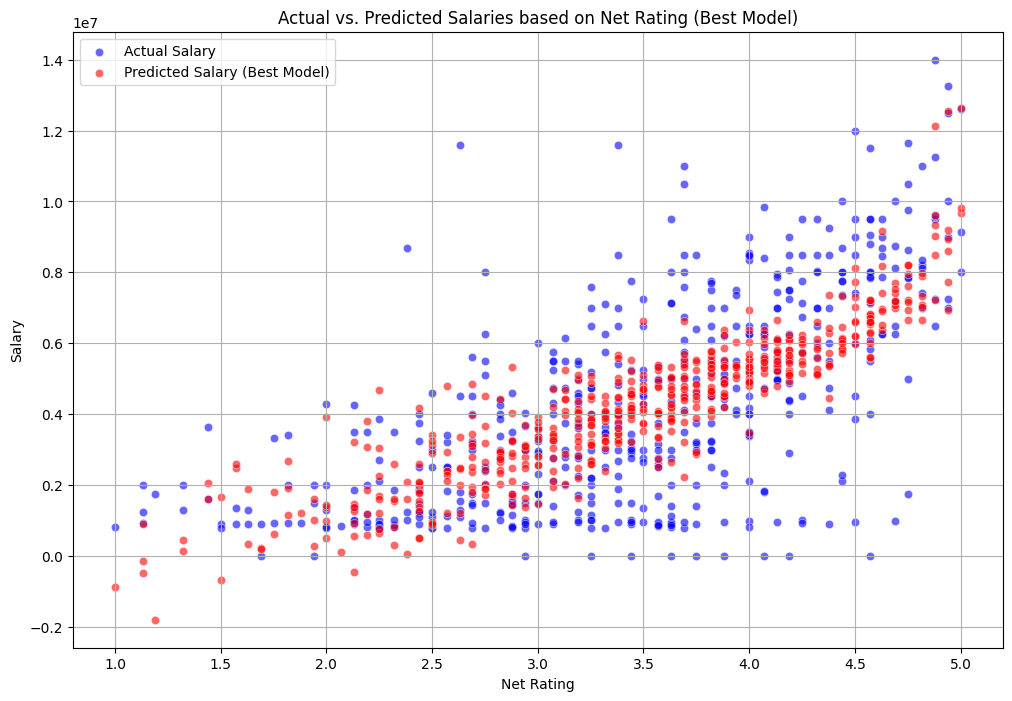

,name,NetRating,capHit,predicted_capHit_best_model
0,Morgan Geekie,4.19,5500000,5.805284e+06
1,Elias Lindholm,3.44,7750000,4.577835e+06
2,David Pastrnak,4.88,11250000,9.014398e+06
3,Pavel Zacha,3.94,4750000,6.030580e+06
4,Casey Mittelstadt,3.07,5750000,4.201537e+06



--- Model Performance Summary (Linear Regression with Multiple Features) ---
Mean Absolute Error (MAE): 1460923.8560825326
R-squared (R2): 0.5755631357393376

--- Insights and Next Steps ---
The Linear Regression model with multiple features achieved an MAE of approximately $1,460,924 and an R-squared of 0.576.
This indicates that the selected features explain about 57.6% of the variance in player salaries, with an average prediction error of around $1,460,924.
Compared to the single‑feature model (Net Rating only), both R-squared and MAE improved, showing that the additional features add meaningful predictive power.

Potential Next Steps:
- Explore more complex models like Ridge, Lasso, Decision Trees, Random Forests, or Gradient Boosting to capture non-linear relationships.
- Consider feature engineering to create more informative features.
- Include additional relevant player statistics (e.g., goals, assists, hits, blocks) and potentially contract details (e.g., term) as features.


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(data=merged_df, x='NetRating', y='capHit', label='Actual Salary', color='blue', alpha=0.6)
sns.scatterplot(data=merged_df, x='NetRating', y='predicted_capHit_best_model', label='Predicted Salary (Best Model)', color='red', alpha=0.6)

plt.xlabel('Net Rating')
plt.ylabel('Salary')
plt.title('Actual vs. Predicted Salaries based on Net Rating (Best Model)')
plt.legend()
plt.grid(True)
plt.show()

# Display a few rows with relevant columns
display(merged_df[['name', 'NetRating', 'capHit', 'predicted_capHit_best_model']].head())

# Summarize model performance and insights
print("\n--- Model Performance Summary (Linear Regression with Multiple Features) ---")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")

print("\n--- Insights and Next Steps ---")
print(f"The Linear Regression model with multiple features achieved an MAE of approximately ${mae:,.0f} and an R-squared of {r2:.3f}.")
print(f"This indicates that the selected features explain about {r2*100:.1f}% of the variance in player salaries, with an average prediction error of around ${mae:,.0f}.")
print("Compared to the single‑feature model (Net Rating only), both R-squared and MAE improved, showing that the additional features add meaningful predictive power.")

print("\nPotential Next Steps:")
print("- Explore more complex models like Ridge, Lasso, Decision Trees, Random Forests, or Gradient Boosting to capture non-linear relationships.")
print("- Consider feature engineering to create more informative features.")
print("- Include additional relevant player statistics (e.g., goals, assists, hits, blocks) and potentially contract details (e.g., term) as features.")
print("- Perform hyperparameter tuning for the selected models to optimize performance.")
print("- Analyze the residuals to understand where the model performs poorly and identify potential outliers or influential data points.")

<p align="center">
  <img src="https://capwages.com/https://capwages.com/images/hockey-bg.jpg
" alt="CapWages Logo" width="300"/>
</p>